In [ ]:
!pip install roboflow pycocotools kornia segment-anything -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.2 MB/s eta 0:00:00


In [ ]:
import os, cv2, json, random

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from PIL import Image
from tqdm import tqdm
from pycocotools.coco import COCO

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader

import kornia.filters as KF

from roboflow import Roboflow
from google.colab import userdata
from scipy.ndimage import distance_transform_edt

from segment_anything import sam_model_registry, SamPredictor

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ROBOFLOW KEY
os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

TimeoutException: Requesting secret ROBOFLOW_API_KEY timed out. Secrets can only be fetched when running from the Colab UI.

In [ ]:
!nvidia-smi

Sun Apr 19 21:01:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   28C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
HOME = os.getcwd()
print(HOME)

/content


## DATASET PREPARATION

In [ ]:
# Access dataset from Roboflow

rf = Roboflow(api_key="Wp24o55YexUp4lOqknub")
project = rf.workspace("segmentation-iugrk").project("crop-field-bopay")
version = project.version(7)
dataset = version.download("coco-segmentation")

print("Dataset location:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Crop-Field-7 in coco-segmentation:: 100%|██████████| 433/433 [00:00<00:00, 5228.09it/s]

Dataset location: /content/Crop-Field-7


In [ ]:
base_dir = dataset.location  # your dataset root

for split in ['train', 'valid', 'test']:
    ann_file = os.path.join(base_dir, split, '_annotations.coco.json')

    if not os.path.exists(ann_file):
        continue

    print(f"\nFixing {split}...")

    with open(ann_file) as f:
        data = json.load(f)

    # -----------------------------
    # 1. Force SINGLE category
    # -----------------------------
    data['categories'] = [{
        "id": 1,
        "name": "field",
        "supercategory": "field"
    }]

    # -----------------------------
    # 2. Fix ALL annotations
    # -----------------------------
    for ann in data['annotations']:
        ann['category_id'] = 1

    # -----------------------------
    # 3. Save
    # -----------------------------
    with open(ann_file, "w") as f:
        json.dump(data, f)

    print(f"  ✓ {split} fixed")

print("\n✅ Dataset fully cleaned!")


Fixing train...
  ✓ train fixed

Fixing valid...
  ✓ valid fixed

Fixing test...
  ✓ test fixed

✅ Dataset fully cleaned!


In [ ]:
# Roboflow coco-segmentation layout:
#   <dataset.location>/
#     train/  _annotations.coco.json  *.jpg
#     valid/  _annotations.coco.json  *.jpg
#     test/   _annotations.coco.json  *.jpg

for split in ['train', 'valid', 'test']:
    split_dir = os.path.join(dataset.location, split)
    ann_file  = os.path.join(split_dir, '_annotations.coco.json')
    if os.path.exists(ann_file):
        with open(ann_file) as f:
            d = json.load(f)
        print(f"[{split}] images: {len(d['images'])}  "
              f"annotations: {len(d['annotations'])}  "
              f"categories: {[c['name'] for c in d['categories']]}")

[train] images: 384  annotations: 8610  categories: ['field']
[valid] images: 30  annotations: 630  categories: ['field']
[test] images: 14  annotations: 161  categories: ['field']


In [ ]:
class CocoSegDataset(Dataset):
    """
    Roboflow coco-segmentation reader.
    Returns (image, seg_mask, boundary_mask, dist_map) for FracTAL multitask training.
      seg_mask      — (H,W) long, class per pixel
      boundary_mask — (H,W) float, 1 at field boundaries
      dist_map      — (H,W) float, normalised distance to nearest boundary
    """
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, split_dir, img_size=512, augment=False):
        ann_file = os.path.join(split_dir, '_annotations.coco.json')
        self.coco      = COCO(ann_file)
        self.img_ids   = list(self.coco.imgs.keys())
        self.split_dir = split_dir
        self.img_size  = img_size
        self.augment   = augment

        cats = self.coco.loadCats(self.coco.getCatIds())
        self.cat2cls     = {c['id']: i+1 for i,c in enumerate(sorted(cats, key=lambda x: x['id']))}
        self.num_classes = len(cats) + 1
        print(f'  {len(self.img_ids)} images | classes: {[c["name"] for c in cats]}')

    def __len__(self): return len(self.img_ids)

    def _build_mask(self, img_id, h, w):
        sem = np.zeros((h,w), dtype=np.uint8)
        for ann in self.coco.loadAnns(self.coco.getAnnIds(imgIds=img_id)):
            rle = self.coco.annToMask(ann)
            sem[rle==1] = self.cat2cls[ann['category_id']]
        return sem

    @staticmethod
    def _make_boundary(mask_np, dilation=2):
        """
        Binary boundary map via erosion difference.

        dilation=4 produces a ~8px wide boundary strip (vs 4px at dilation=2).
        Wider boundaries give the model more positive pixels to learn from and
        make the boundary head signal stronger after Gaussian tile blending.
        The wider strip is also more forgiving of small annotation misalignments.
        """
        import cv2
        field = (mask_np > 0).astype(np.uint8)
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        eroded = cv2.erode(field, k, iterations=dilation)
        boundary = (field - eroded).astype(np.float32)

        # Also mark instance boundaries: pixels where adjacent field instances differ
        # This catches inter-field boundaries that erosion alone misses when two
        # fields share an edge with no gap in the annotation
        instance_bound = np.zeros_like(boundary)
        sem = mask_np.astype(np.int32)
        h_diff = (sem[:-1, :] != sem[1:,  :]).astype(np.float32)
        v_diff = (sem[:, :-1] != sem[:,  1:]).astype(np.float32)
        instance_bound[:-1, :] = np.maximum(instance_bound[:-1, :], h_diff)
        instance_bound[1:,  :] = np.maximum(instance_bound[1:,  :], h_diff)
        instance_bound[:, :-1] = np.maximum(instance_bound[:, :-1], v_diff)
        instance_bound[:,  1:] = np.maximum(instance_bound[:,  1:], v_diff)
        # Dilate instance boundaries to match erosion width
        k2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        instance_bound = cv2.dilate(instance_bound.astype(np.uint8), k2,
                                    iterations=dilation).astype(np.float32)

        return np.clip(boundary + instance_bound, 0.0, 1.0)

    @staticmethod
    def _make_distance(boundary_np):
        """
        Normalised distance from each pixel to nearest boundary, clipped to
        a maximum of 64px before normalising.

        Clipping prevents large fields from having very high distance values
        that dominate the MSE loss and overshadow small-field interior pixels.
        The model learns a plateau-shaped distance map rather than a tent,
        which is more robust for fields of varying size.
        """
        from scipy.ndimage import distance_transform_edt
        non_boundary = (boundary_np == 0).astype(np.uint8)
        dist = distance_transform_edt(non_boundary).astype(np.float32)
        dist = np.clip(dist, 0.0, 64.0)   # cap at 64px
        if dist.max() > 0:
            dist = dist / dist.max()
        return dist

    def __getitem__(self, idx):
        img_id  = self.img_ids[idx]
        info    = self.coco.imgs[img_id]
        img     = Image.open(os.path.join(self.split_dir, info['file_name'])).convert('RGB')
        mask_np = self._build_mask(img_id, info['height'], info['width'])

        # Build auxiliary targets from mask (before resizing to preserve precision)
        boundary_np = self._make_boundary(mask_np)
        dist_np     = self._make_distance(boundary_np)

        mask     = Image.fromarray(mask_np)
        boundary = Image.fromarray((boundary_np * 255).astype(np.uint8))
        dist_img = Image.fromarray((dist_np     * 255).astype(np.uint8))

        # ── Multi-scale resize ────────────────────────────────────────────────
        if self.augment:
            scale = random.uniform(0.75, 1.25)
            size  = max(int(self.img_size * scale) // 32 * 32, 32)
        else:
            size = self.img_size

        nn_mode = TF.InterpolationMode.NEAREST
        img      = TF.resize(img,      [size, size])
        mask     = TF.resize(mask,     [size, size], interpolation=nn_mode)
        boundary = TF.resize(boundary, [size, size], interpolation=nn_mode)
        dist_img = TF.resize(dist_img, [size, size], interpolation=nn_mode)

        img      = TF.center_crop(img,      self.img_size)
        mask     = TF.center_crop(mask,     self.img_size)
        boundary = TF.center_crop(boundary, self.img_size)
        dist_img = TF.center_crop(dist_img, self.img_size)

        # ── Augmentation (same transform applied to all) ───────────────────
        if self.augment:
            if random.random() > 0.5:
                img,mask,boundary,dist_img = (TF.hflip(x) for x in [img,mask,boundary,dist_img])
            if random.random() > 0.5:
                img,mask,boundary,dist_img = (TF.vflip(x) for x in [img,mask,boundary,dist_img])
            if random.random() > 0.3:
                angle = random.uniform(-20,20)
                img,mask,boundary,dist_img = (TF.rotate(x,angle) for x in [img,mask,boundary,dist_img])
            if random.random() > 0.5:
                jitter = T.ColorJitter(brightness=0.3,contrast=0.3,saturation=0.2,hue=0.1)
                img = jitter(img)
            # Gaussian blur augmentation: teaches model to handle soft boundaries
            if random.random() > 0.7:
                sigma = random.uniform(0.3, 1.5)
                img = TF.gaussian_blur(img, kernel_size=5, sigma=sigma)

        # ── To tensor ─────────────────────────────────────────────────────────
        img      = TF.normalize(TF.to_tensor(img), mean=self.MEAN, std=self.STD)
        mask     = torch.as_tensor(np.array(mask),     dtype=torch.long)
        boundary = torch.as_tensor(np.array(boundary), dtype=torch.float32) / 255.0
        dist_map = torch.as_tensor(np.array(dist_img), dtype=torch.float32) / 255.0

        return img, mask, boundary, dist_map

# MODEL TRAINING

In [ ]:
IMG_SIZE = 512
BATCH    = 8
WORKERS  = 4

train_ds = CocoSegDataset(os.path.join(dataset.location,'train'), IMG_SIZE, augment=True)
val_ds   = CocoSegDataset(os.path.join(dataset.location,'valid'), IMG_SIZE, augment=False)

NUM_CLASSES = train_ds.num_classes
print(f'NUM_CLASSES = {NUM_CLASSES}')

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                           num_workers=WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                           num_workers=WORKERS, pin_memory=True)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

loading annotations into memory...
Done (t=0.06s)
creating index...
index created!
  384 images | classes: ['field']
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
  30 images | classes: ['field']
NUM_CLASSES = 2
Train batches: 48 | Val batches: 4


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# SAM-FracTAL ResUNet
#
# Architecture overview:
#
#   Image ──┬──► SAM ViT encoder (frozen) ──► 32×32 @ 256ch
#            │         └─────────────────────────────────────────────────────┐
#            └──► FracTAL encoder                                            │
#                   enc1 → 256×256 @ 32ch  (skip s1)                        │
#                   enc2 → 128×128 @ 64ch  (skip s2)                        │
#                   enc3 →  64×64  @ 128ch (skip s3)                        │
#                   enc4 →  32×32  @ 256ch (skip s4)                        │
#                   bottleneck → 32×32 @ 512ch                               │
#                        └── SAMFusion (cross-attention with SAM features) ◄─┘
#                   decoder → 256×256 @ 32ch
#                   seg | boundary | dist heads
#
# SAMFusion module:
#   SAM's image encoder produces a 32×32 feature map with rich semantic
#   understanding of object boundaries and regions — exactly what FracTAL's
#   bottleneck needs to understand full field extents.
#
#   The fusion uses cross-attention: FracTAL bottleneck features are the
#   Query, SAM features are Key and Value. A learned projection first maps
#   SAM's 256 channels to match FracTAL's bottleneck width (512).
#   A residual gate (learned scalar α) controls how strongly SAM features
#   modulate the bottleneck — starts near 0, grows as training stabilises.
#
# Why cross-attention (not simple concat)?
#   Concat would require the decoder to always process SAM features even
#   when they're redundant. Cross-attention lets the model selectively
#   query SAM for the spatial regions where FracTAL is uncertain (field
#   interiors and edges) while ignoring SAM noise elsewhere.
#
# Memory: SAM ViT-B encoder = 89M params (frozen). Only SAMFusion (≈300K)
#   and FracTAL (21.8M) train. Total trainable ≈ 22.1M — same GPU budget.
# ════════════════════════════════════════════════════════════════════════════

In [ ]:
# ── SAM preprocessing constants (matches SAM's internal normalisation) ────────
SAM_PIXEL_MEAN = torch.tensor([123.675, 116.280, 103.530]).view(1,3,1,1)
SAM_PIXEL_STD  = torch.tensor([ 58.395,  57.120,  57.375]).view(1,3,1,1)


class SAMFeatureExtractor(nn.Module):
    """
    Wraps SAM's image encoder (ViT) as a frozen feature extractor.

    Input:  (B, 3, H, W)  — ImageNet-normalised (FracTAL convention)
    Output: (B, 256, H/16, W/16)  — SAM image embeddings

    The module re-normalises the input from ImageNet stats to SAM's pixel
    stats before passing through ViT, so both models see their expected input.

    All parameters are frozen — gradients never flow into ViT.
    """
    def __init__(self, sam_checkpoint: str, model_type: str = 'vit_b'):
        super().__init__()
        sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
        self.image_encoder = sam.image_encoder
        # Freeze all SAM parameters
        for p in self.image_encoder.parameters():
            p.requires_grad = False
        self.register_buffer('pixel_mean', SAM_PIXEL_MEAN)
        self.register_buffer('pixel_std',  SAM_PIXEL_STD)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: ImageNet-normalised (B,3,H,W) — denormalise then renormalise for SAM
        imagenet_mean = torch.tensor([0.485,0.456,0.406], device=x.device).view(1,3,1,1)
        imagenet_std  = torch.tensor([0.229,0.224,0.225], device=x.device).view(1,3,1,1)
        x_01    = x * imagenet_std + imagenet_mean          # back to [0,1]
        x_sam   = (x_01 * 255.0 - self.pixel_mean) / self.pixel_std  # SAM space
        # SAM ViT expects 1024×1024; resize if needed
        if x_sam.shape[-1] != 1024:
            x_sam = F.interpolate(x_sam, size=(1024, 1024),
                                  mode='bilinear', align_corners=False)
        with torch.no_grad():
            feats = self.image_encoder(x_sam)  # (B, 256, 64, 64) for ViT-B
        return feats


class SAMFusion(nn.Module):
    """
    Cross-attention fusion of SAM features into FracTAL's bottleneck.

    Query  = FracTAL bottleneck features  (B, fractal_ch, H, W)
    Key,V  = SAM image embeddings         (B, sam_ch,     H, W)

    Steps:
      1. Project SAM channels → fractal_ch  (1×1 conv)
      2. Flatten spatial dims → sequence length
      3. Multi-head cross-attention (8 heads, fractal_ch dims)
      4. Reshape back to spatial map
      5. Residual gate:  out = fractal_feat + α * attended_sam
         α is a learned scalar initialised to 0.0 so fusion starts disabled
         and is gradually activated by the optimiser as it proves useful.
    """
    def __init__(self, fractal_ch: int, sam_ch: int = 256, n_heads: int = 8):
        super().__init__()
        self.sam_proj  = nn.Conv2d(sam_ch, fractal_ch, 1, bias=False)
        self.norm_q    = nn.LayerNorm(fractal_ch)
        self.norm_kv   = nn.LayerNorm(fractal_ch)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim   = fractal_ch,
            num_heads   = n_heads,
            batch_first = True,
            dropout     = 0.0,
        )
        self.proj_out  = nn.Sequential(
            nn.Linear(fractal_ch, fractal_ch),
            nn.GELU(),
            nn.Linear(fractal_ch, fractal_ch),
        )
        # Residual gate — initialised to 0 so fusion starts as identity
        self.alpha = nn.Parameter(torch.zeros(1))

    def forward(self, fractal_feat: torch.Tensor,
                sam_feat: torch.Tensor) -> torch.Tensor:
        B, C, H, W = fractal_feat.shape

        # Align SAM spatial resolution to FracTAL bottleneck resolution
        sam_proj = self.sam_proj(sam_feat)              # (B, C, sam_H, sam_W)
        if sam_proj.shape[-2:] != (H, W):
            sam_proj = F.interpolate(sam_proj, size=(H, W),
                                     mode='bilinear', align_corners=False)

        # Flatten spatial → sequence  (B, H*W, C)
        q  = fractal_feat.flatten(2).permute(0, 2, 1)  # (B, HW, C)
        kv = sam_proj.flatten(2).permute(0, 2, 1)      # (B, HW, C)

        q  = self.norm_q(q)
        kv = self.norm_kv(kv)

        attended, _ = self.cross_attn(q, kv, kv)       # (B, HW, C)
        attended    = self.proj_out(attended)            # (B, HW, C)

        # Reshape back and apply residual gate
        attended    = attended.permute(0, 2, 1).view(B, C, H, W)
        return fractal_feat + torch.tanh(self.alpha) * attended


# ── FracTAL ResUNet components (unchanged) ───────────────────────────────────

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(channels, max(channels//reduction, 4)), nn.ReLU(),
            nn.Linear(max(channels//reduction, 4), channels), nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.fc(x).view(x.size(0), x.size(1), 1, 1)


class SpatialAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 1)
        self.sig  = nn.Sigmoid()
    def forward(self, x):
        return x * self.sig(self.conv(x))


class FracTALUnit(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ch_att = ChannelAttention(channels)
        self.sp_att = SpatialAttention(channels)
        self.alpha  = nn.Parameter(torch.tensor(0.5))
    def forward(self, x):
        a = torch.clamp(self.alpha, 0.0, 1.0)
        return a * self.ch_att(x) + (1-a) * self.sp_att(x)


class FracTALResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dilation=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.BatchNorm2d(in_ch), nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 3, padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=dilation, dilation=dilation, bias=False),
        )
        self.fractal = FracTALUnit(out_ch)
        self.proj    = nn.Conv2d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        return self.proj(x) + self.fractal(self.conv(x))


class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, n_blocks=2, dilation=1):
        super().__init__()
        blocks = [FracTALResBlock(in_ch, out_ch, dilation)]
        for _ in range(n_blocks-1):
            blocks.append(FracTALResBlock(out_ch, out_ch, dilation))
        self.blocks = nn.Sequential(*blocks)
        self.pool   = nn.MaxPool2d(2)
    def forward(self, x):
        skip = self.blocks(x)
        return self.pool(skip), skip


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up    = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.block = FracTALResBlock(out_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return self.block(torch.cat([x, skip], dim=1))


# ── SAM-FracTAL ResUNet (the combined model) ─────────────────────────────────

class SAMFracTALResUNet(nn.Module):
    """
    SAM-FracTAL ResUNet.

    SAM ViT-B image encoder is embedded as a frozen feature extractor.
    Its output is fused into the FracTAL bottleneck via SAMFusion
    (cross-attention + learned residual gate).

    Forward pass:
      x → SAMFeatureExtractor  → sam_feats (B, 256, 64, 64)   [no grad]
      x → FracTAL encoder      → s1,s2,s3,s4, bottleneck
      bottleneck + sam_feats   → SAMFusion → enriched bottleneck
      enriched bottleneck      → FracTAL decoder → seg/bound/dist heads

    save_state_dict() saves ONLY trainable parameters (FracTAL + SAMFusion).
    The SAM checkpoint is loaded separately at inference, keeping checkpoints small.
    """
    def __init__(self, sam_checkpoint: str, sam_model_type: str = 'vit_b',
                 num_classes: int = 2, base_ch: int = 32):
        super().__init__()
        c = base_ch

        # ── Frozen SAM image encoder ─────────────────────────────────────
        self.sam_encoder = SAMFeatureExtractor(sam_checkpoint, sam_model_type)
        # SAM ViT-B outputs 256 channels; ViT-H outputs 256 too (after neck)
        sam_ch = 256

        # ── FracTAL encoder ───────────────────────────────────────────────
        self.enc1       = EncoderBlock(3,    c,    n_blocks=2)
        self.enc2       = EncoderBlock(c,    c*2,  n_blocks=2)
        self.enc3       = EncoderBlock(c*2,  c*4,  n_blocks=3)
        self.enc4       = EncoderBlock(c*4,  c*8,  n_blocks=3)
        self.bottleneck = nn.Sequential(
            FracTALResBlock(c*8,  c*16, dilation=2),
            FracTALResBlock(c*16, c*16, dilation=4),
            FracTALResBlock(c*16, c*16, dilation=2),
        )

        # ── SAM → bottleneck fusion ───────────────────────────────────────
        # FracTAL bottleneck width is c*16 = 512 (for base_ch=32)
        self.sam_fusion = SAMFusion(fractal_ch=c*16, sam_ch=sam_ch, n_heads=8)

        # ── FracTAL decoder ───────────────────────────────────────────────
        self.dec4 = DecoderBlock(c*16, c*8,  c*8)
        self.dec3 = DecoderBlock(c*8,  c*4,  c*4)
        self.dec2 = DecoderBlock(c*4,  c*2,  c*2)
        self.dec1 = DecoderBlock(c*2,  c,    c)

        # ── Output heads (unchanged) ──────────────────────────────────────
        self.seg_head   = nn.Conv2d(c, num_classes, 1)
        self.bound_head = nn.Conv2d(c, 1, 1)
        self.dist_head  = nn.Conv2d(c, 1, 1)

    def forward(self, x: torch.Tensor) -> dict:
        # 1. SAM features (frozen, no gradient)
        sam_feats = self.sam_encoder(x)          # (B, 256, 64, 64)

        # 2. FracTAL encode
        x, s1 = self.enc1(x)
        x, s2 = self.enc2(x)
        x, s3 = self.enc3(x)
        x, s4 = self.enc4(x)
        x     = self.bottleneck(x)               # (B, 512, 32, 32)

        # 3. Fuse SAM into bottleneck via cross-attention
        x = self.sam_fusion(x, sam_feats)        # (B, 512, 32, 32)

        # 4. FracTAL decode
        x = self.dec4(x, s4)
        x = self.dec3(x, s3)
        x = self.dec2(x, s2)
        x = self.dec1(x, s1)

        return {
            'seg':   self.seg_head(x),
            'bound': self.bound_head(x),
            'dist':  self.dist_head(x),
        }

    def trainable_state_dict(self):
        """Save only FracTAL + SAMFusion weights (not the frozen SAM ViT)."""
        return {k: v for k, v in self.state_dict().items()
                if not k.startswith('sam_encoder.image_encoder')}

    def load_trainable_state_dict(self, state_dict):
        """Load FracTAL + SAMFusion weights; SAM ViT stays untouched."""
        missing, unexpected = self.load_state_dict(state_dict, strict=False)
        sam_keys = [k for k in missing if k.startswith('sam_encoder')]
        other_missing = [k for k in missing if not k.startswith('sam_encoder')]
        if other_missing:
            print(f'  ⚠ Missing non-SAM keys: {other_missing}')
        return self

In [ ]:
SAM_CHECKPOINT = '/content/drive/MyDrive/AGRI/TreeCrown_Segmentation/models/segmentation/sam_vit_b_01ec64.pth'
SAM_MODEL_TYPE = 'vit_b'   # ViT-B: 89M frozen params, 256-ch output, fits T4

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

model = SAMFracTALResUNet(
    sam_checkpoint = SAM_CHECKPOINT,
    sam_model_type = SAM_MODEL_TYPE,
    num_classes    = NUM_CLASSES,
    base_ch        = 32,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params
print(f'Total params      : {total_params:,}')
print(f'Trainable params  : {trainable_params:,}   ← FracTAL + SAMFusion only')
print(f'Frozen params     : {frozen_params:,}   ← SAM ViT-B image encoder')
print(f'SAM fusion gate α : {model.sam_fusion.alpha.item():.4f}  (starts at 0 = identity)')

# Sanity check — full forward pass
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    for k, v in out.items():
        print(f'  {k}: {tuple(v.shape)}')

Device: cuda
Total params      : 113,255,316
Trainable params  : 23,584,404   ← FracTAL + SAMFusion only
Frozen params     : 89,670,912   ← SAM ViT-B image encoder
SAM fusion gate α : 0.0000  (starts at 0 = identity)
  seg: (2, 2, 512, 512)
  bound: (2, 1, 512, 512)
  dist: (2, 1, 512, 512)


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Loss functions — UNCHANGED from original FracTAL training
# The SAM fusion improves features; the supervision targets stay the same.
# ════════════════════════════════════════════════════════════════════════════

LAMBDA_BOUND = 3.0
LAMBDA_DIST  = 1.0
LAMBDA_DICE  = 2.0


def dice_loss(logits, targets, num_classes, smooth=1.0):
    probs = torch.softmax(logits, dim=1)
    loss  = 0.0
    for cls in range(num_classes):
        p = probs[:, cls]
        t = (targets == cls).float()
        inter = (p * t).sum(dim=(1, 2))
        union = p.sum(dim=(1, 2)) + t.sum(dim=(1, 2))
        loss += (1.0 - (2.0 * inter + smooth) / (union + smooth)).mean()
    return loss / num_classes


def boundary_f1(pred_bound_logits, true_bound, thresh=0.5):
    pred = (torch.sigmoid(pred_bound_logits.squeeze(1)) > thresh)
    true = (true_bound > 0.5)
    tp = (pred & true).sum().item()
    fp = (pred & ~true).sum().item()
    fn = (~pred & true).sum().item()
    prec = tp / max(tp + fp, 1)
    rec  = tp / max(tp + fn, 1)
    f1   = 2 * prec * rec / max(prec + rec, 1e-6)
    return f1, prec, rec


def fractal_loss(out, masks, boundaries, dist_maps, num_classes):
    ce         = F.cross_entropy(out['seg'], masks, reduction='none')
    weight_map = 1.0 + 12.0 * boundaries
    l_seg_ce   = (ce * weight_map).mean()
    l_seg_dice = dice_loss(out['seg'], masks, num_classes)
    l_seg      = l_seg_ce + LAMBDA_DICE * l_seg_dice

    pos_weight = torch.tensor([20.0], device=boundaries.device)
    l_bound    = F.binary_cross_entropy_with_logits(
        out['bound'].squeeze(1), boundaries, pos_weight=pos_weight)

    field_mask = (masks > 0).float()
    dist_pred  = torch.sigmoid(out['dist'].squeeze(1))
    l_dist     = (F.mse_loss(dist_pred, dist_maps, reduction='none') * field_mask).mean()

    total = l_seg + LAMBDA_BOUND * l_bound + LAMBDA_DIST * l_dist
    return total, l_seg_ce, l_seg_dice, l_bound, l_dist


def mean_iou(pred_mask, true_mask, num_classes):
    ious = []
    for cls in range(num_classes):
        inter = ((pred_mask == cls) & (true_mask == cls)).sum().item()
        union = ((pred_mask == cls) | (true_mask == cls)).sum().item()
        if union > 0:
            ious.append(inter / union)
    return float(np.mean(ious)) if ious else 0.0


def run_epoch(model, loader, optimizer, device, num_classes, train=True):
    model.train() if train else model.eval()
    tot_loss = tot_ce = tot_dice = tot_bound = tot_dist = tot_iou = tot_bf1 = n = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, masks, boundaries, dist_maps in tqdm(
                loader, desc='train' if train else 'val ', leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            boundaries  = boundaries.to(device)
            dist_maps   = dist_maps.to(device)

            out = model(imgs)
            loss, l_ce, l_dice, l_b, l_d = fractal_loss(
                out, masks, boundaries, dist_maps, num_classes)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            preds     = out['seg'].argmax(dim=1)
            bf1, _, _ = boundary_f1(out['bound'], boundaries)
            tot_loss  += loss.item(); tot_ce    += l_ce.item()
            tot_dice  += l_dice.item(); tot_bound += l_b.item()
            tot_dist  += l_d.item()
            tot_iou   += mean_iou(preds.cpu(), masks.cpu(), num_classes)
            tot_bf1   += bf1
            n += 1

    return (tot_loss/n, tot_ce/n, tot_dice/n, tot_bound/n, tot_dist/n,
            tot_iou/n, tot_bf1/n)

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Optimizer — two parameter groups with different learning rates
#
# SAMFusion gets 10× lower LR than FracTAL for the first 30 epochs.
# Rationale: the cross-attention starts as identity (α=0). Ramping it up
# too fast before FracTAL's encoder has stabilised introduces noisy gradients
# from the SAM features. The lower LR lets FracTAL converge on its own first,
# then SAMFusion grows its contribution gradually as α is pushed away from 0.
# ════════════════════════════════════════════════════════════════════════════

EPOCHS     = 120
LR         = 1e-4
WARMUP     = 5
OUTPUT_DIR = '/content/drive/MyDrive/AGRI/CropField_Segmentation/result/sam-fractal-resunet-512-v02'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Separate parameter groups: SAMFusion trains slower initially
sam_fusion_params = list(model.sam_fusion.parameters())
fractal_params    = [p for p in model.parameters()
                     if p.requires_grad and
                     not any(p is q for q in sam_fusion_params)]

optimizer = optim.AdamW([
    {'params': fractal_params,    'lr': LR,        'name': 'fractal'},
    {'params': sam_fusion_params, 'lr': LR * 0.1,  'name': 'sam_fusion'},
], weight_decay=1e-4)

def lr_lambda(epoch):
    if epoch < WARMUP:
        return (epoch + 1) / WARMUP
    progress = (epoch - WARMUP) / max(EPOCHS - WARMUP, 1)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f'FracTAL params     : {sum(p.numel() for p in fractal_params):,}  LR={LR:.1e}')
print(f'SAMFusion params   : {sum(p.numel() for p in sam_fusion_params):,}  LR={LR*0.1:.1e}')

FracTAL params     : 21,875,347  LR=1.0e-04
SAMFusion params   : 1,709,057  LR=1.0e-05


In [ ]:
best_bf1 = 0.0
history  = {'train_loss': [], 'val_loss': [],
            'train_iou':  [], 'val_iou':  [],
            'train_bf1':  [], 'val_bf1':  [],
            'sam_alpha':  []}

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(model, train_loader, optimizer, DEVICE, NUM_CLASSES, train=True)
    vl = run_epoch(model, val_loader,   optimizer, DEVICE, NUM_CLASSES, train=False)
    scheduler.step()

    tr_loss, tr_ce, tr_dice, tr_bnd, tr_dst, tr_iou, tr_bf1 = tr
    vl_loss, vl_ce, vl_dice, vl_bnd, vl_dst, vl_iou, vl_bf1 = vl

    # Track how much the SAM fusion gate has opened
    alpha_val = float(torch.tanh(model.sam_fusion.alpha).item())

    history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
    history['train_iou'].append(tr_iou);   history['val_iou'].append(vl_iou)
    history['train_bf1'].append(tr_bf1);   history['val_bf1'].append(vl_bf1)
    history['sam_alpha'].append(alpha_val)

    lr_now = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch:3d}/{EPOCHS} | LR={lr_now:.2e} | α(SAM)={alpha_val:.3f} | '
          f'Loss {tr_loss:.3f}/{vl_loss:.3f} | '
          f'CE {tr_ce:.3f}/{vl_ce:.3f} | Dice {tr_dice:.3f}/{vl_dice:.3f} | '
          f'Bnd {tr_bnd:.3f}/{vl_bnd:.3f} | '
          f'mIoU {tr_iou:.4f}/{vl_iou:.4f} | BndF1 {tr_bf1:.4f}/{vl_bf1:.4f}')

    if vl_bf1 > best_bf1:
        best_bf1 = vl_bf1
        # Save only trainable weights — SAM ViT is loaded separately at inference
        torch.save(model.trainable_state_dict(),
                   os.path.join(OUTPUT_DIR, 'best.pt'))
        print(f'  ✓ New best val BoundaryF1: {best_bf1:.4f}  (mIoU={vl_iou:.4f})')

    torch.save({
        'epoch':      epoch,
        'state_dict': model.trainable_state_dict(),
        'optimizer':  optimizer.state_dict(),
        'scheduler':  scheduler.state_dict(),
        'best_bf1':   best_bf1,
        'history':    history,
    }, os.path.join(OUTPUT_DIR, 'last.pt'))

print(f'\nTraining complete. Best val BoundaryF1: {best_bf1:.4f}')
print(f'Final SAM fusion gate α = {float(torch.tanh(model.sam_fusion.alpha).item()):.4f}')
print(f'  α≈0: SAM barely used | α≈1: SAM strongly influences bottleneck')

Epoch   1/120 | LR=4.00e-05 | α(SAM)=0.000 | Loss 7.824/7.632 | CE 1.434/1.389 | Dice 0.522/0.546 | Bnd 1.759/1.691 | mIoU 0.3750/0.4634 | BndF1 0.1774/0.1776
  ✓ New best val BoundaryF1: 0.1776  (mIoU=0.4634)


Epoch   2/120 | LR=6.00e-05 | α(SAM)=0.000 | Loss 7.042/6.602 | CE 1.363/1.307 | Dice 0.489/0.517 | Bnd 1.543/1.393 | mIoU 0.5950/0.6113 | BndF1 0.2096/0.1975
  ✓ New best val BoundaryF1: 0.1975  (mIoU=0.6113)


Epoch   3/120 | LR=8.00e-05 | α(SAM)=0.000 | Loss 6.097/5.874 | CE 1.256/1.227 | Dice 0.439/0.481 | Bnd 1.298/1.202 | mIoU 0.6647/0.6086 | BndF1 0.2287/0.2533
  ✓ New best val BoundaryF1: 0.2533  (mIoU=0.6086)


Epoch   4/120 | LR=1.00e-04 | α(SAM)=0.001 | Loss 5.415/5.243 | CE 1.176/1.121 | Dice 0.387/0.424 | Bnd 1.134/1.066 | mIoU 0.6886/0.7203 | BndF1 0.3037/0.3582
  ✓ New best val BoundaryF1: 0.3582  (mIoU=0.7203)


Epoch   5/120 | LR=1.00e-04 | α(SAM)=0.001 | Loss 5.031/4.712 | CE 1.131/1.027 | Dice 0.343/0.351 | Bnd 1.051/0.971 | mIoU 0.7100/0.7623 | BndF1 0.3527/0.3769
  ✓ New best val BoundaryF1: 0.3769  (mIoU=0.7623)


...

Epoch 116/120 | LR=2.98e-07 | α(SAM)=0.012 | Loss 1.937/2.991 | CE 0.650/0.817 | Dice 0.070/0.107 | Bnd 0.378/0.647 | mIoU 0.9313/0.9056 | BndF1 0.6297/0.6150


Epoch 117/120 | LR=1.68e-07 | α(SAM)=0.012 | Loss 1.932/2.947 | CE 0.651/0.807 | Dice 0.070/0.108 | Bnd 0.376/0.635 | mIoU 0.9306/0.9049 | BndF1 0.6299/0.6124


Epoch 118/120 | LR=7.46e-08 | α(SAM)=0.012 | Loss 1.908/3.008 | CE 0.648/0.809 | Dice 0.071/0.105 | Bnd 0.369/0.656 | mIoU 0.9321/0.9087 | BndF1 0.6360/0.6156


Epoch 119/120 | LR=1.87e-08 | α(SAM)=0.012 | Loss 1.915/2.957 | CE 0.647/0.801 | Dice 0.068/0.104 | Bnd 0.374/0.642 | mIoU 0.9311/0.9099 | BndF1 0.6340/0.6152


Epoch 120/120 | LR=0.00e+00 | α(SAM)=0.012 | Loss 1.910/2.996 | CE 0.644/0.810 | Dice 0.069/0.106 | Bnd 0.372/0.651 | mIoU 0.9322/0.9078 | BndF1 0.6343/0.6164

Training complete. Best val BoundaryF1: 0.6171
Final SAM fusion gate α = 0.0123
  α≈0: SAM barely used | α≈1: SAM strongly influences bottleneck


## VISUALIZATION

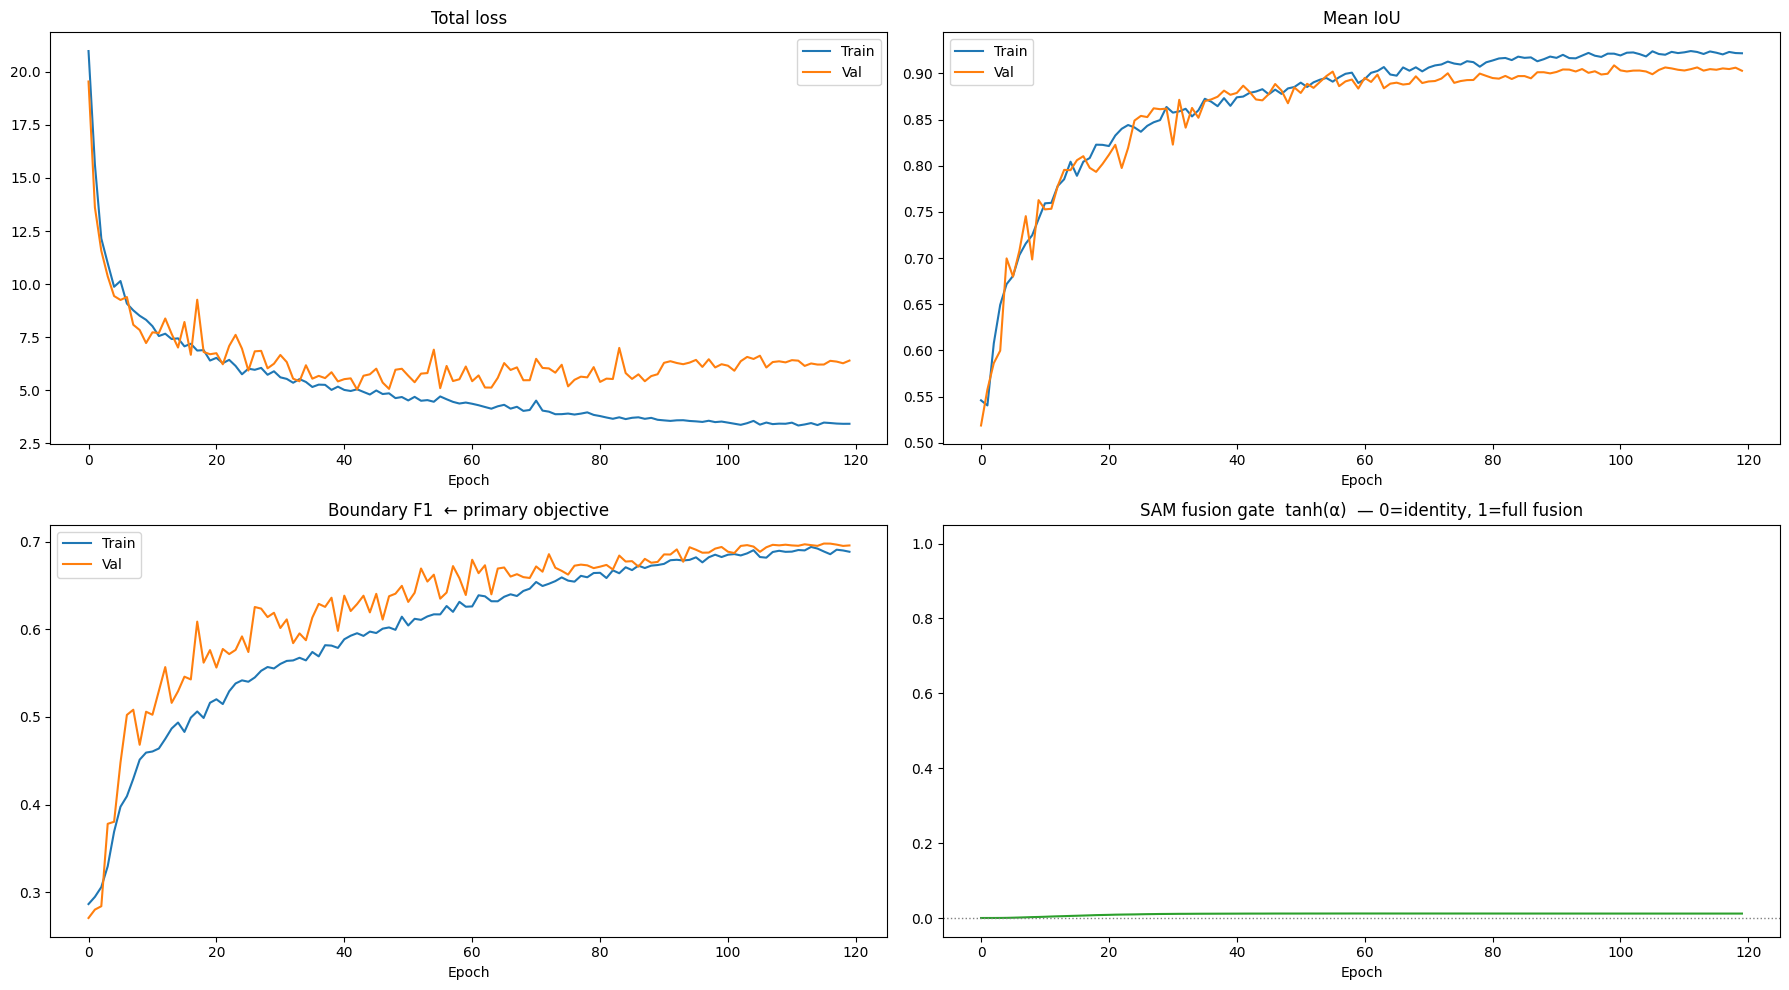

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

axes[0,0].plot(history['train_loss'], label='Train')
axes[0,0].plot(history['val_loss'],   label='Val')
axes[0,0].set_title('Total loss'); axes[0,0].set_xlabel('Epoch'); axes[0,0].legend()

axes[0,1].plot(history['train_iou'], label='Train')
axes[0,1].plot(history['val_iou'],   label='Val')
axes[0,1].set_title('Mean IoU'); axes[0,1].set_xlabel('Epoch'); axes[0,1].legend()

axes[1,0].plot(history['train_bf1'], label='Train')
axes[1,0].plot(history['val_bf1'],   label='Val')
axes[1,0].set_title('Boundary F1  ← primary objective')
axes[1,0].set_xlabel('Epoch'); axes[1,0].legend()

axes[1,1].plot(history['sam_alpha'], color='tab:green')
axes[1,1].axhline(0, color='gray', linestyle=':', linewidth=1)
axes[1,1].set_title('SAM fusion gate  tanh(α)  — 0=identity, 1=full fusion')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

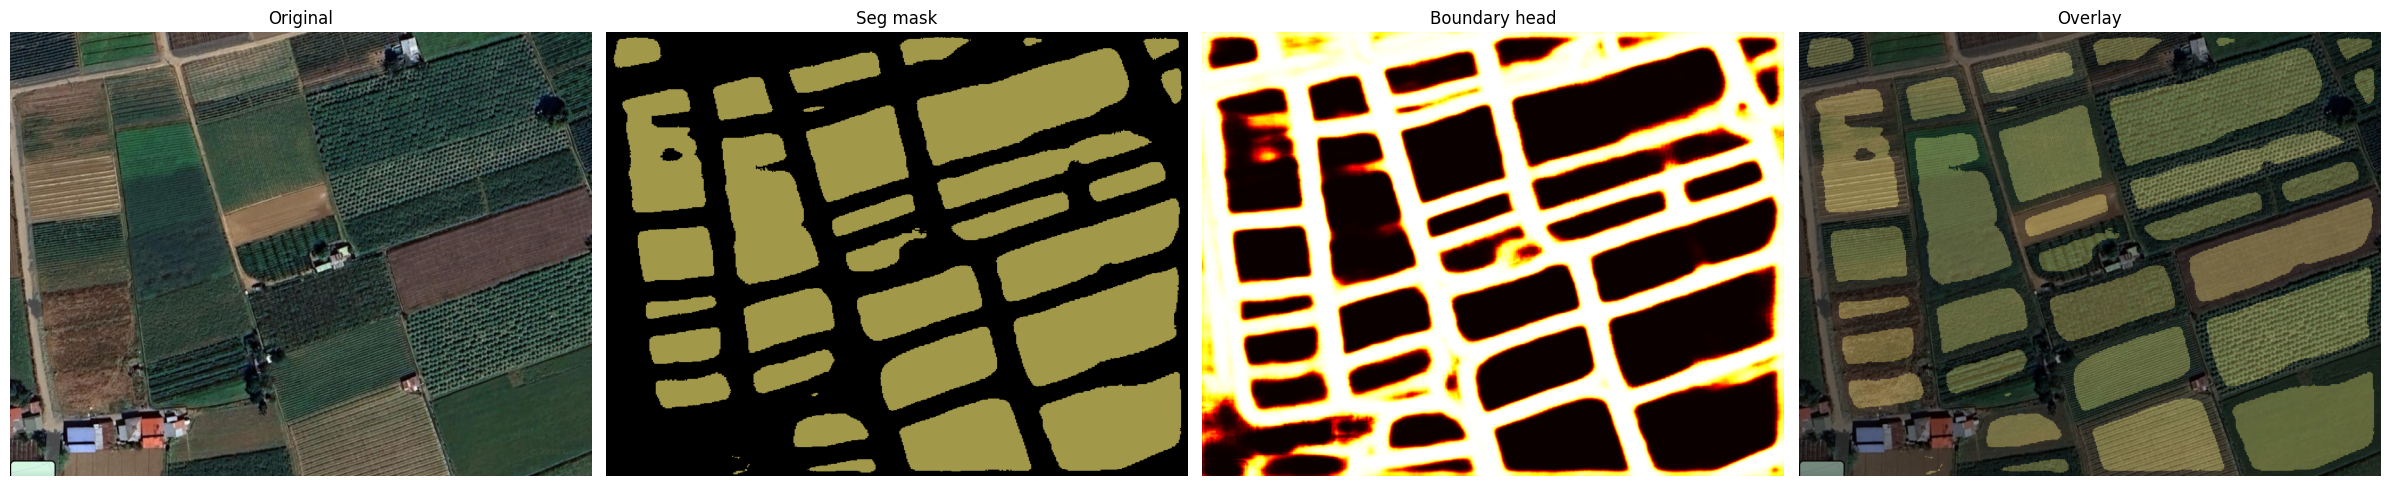

Field coverage   : 47.5%
SAM fusion gate  : α = 0.0118


In [ ]:
CHECKPOINT = os.path.join(OUTPUT_DIR, 'best.pt')
IMG_PATH   = '/content/drive/MyDrive/AGRI/CropField_Segmentation/Screenshot 2026-03-17 063235.png'

model.load_trainable_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()

img_pil = Image.open(IMG_PATH).convert('RGB')
orig_w, orig_h = img_pil.size

preprocess = T.Compose([
    T.Resize([IMG_SIZE, IMG_SIZE]),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
input_tensor = preprocess(img_pil).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    out = model(input_tensor)

pred_mask  = out['seg'].argmax(dim=1).squeeze().cpu().numpy()
pred_bound = torch.sigmoid(out['bound']).squeeze().cpu().numpy()

BOUND_THRESH  = 0.50
hard_bound    = (pred_bound > BOUND_THRESH).astype(np.uint8)
pred_mask_cut = pred_mask.copy()
pred_mask_cut[hard_bound == 1] = 0

def resize_map(arr, w, h, interp=Image.NEAREST):
    return np.array(Image.fromarray(arr.astype(np.uint8)).resize((w, h), interp))

pred_mask_full  = resize_map(pred_mask_cut, orig_w, orig_h)
pred_bound_full = resize_map((pred_bound*255).astype(np.uint8), orig_w, orig_h, Image.BILINEAR)

orig_arr = np.array(img_pil)
np.random.seed(42)
PALETTE    = [(0,0,0)] + [tuple(np.random.randint(60,230,3).tolist()) for _ in range(NUM_CLASSES-1)]
color_mask = np.zeros((*pred_mask_full.shape, 3), dtype=np.uint8)
for cls_id, rgb in enumerate(PALETTE):
    color_mask[pred_mask_full==cls_id] = rgb
overlay = (0.55*orig_arr + 0.45*color_mask).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes[0].imshow(orig_arr);          axes[0].set_title('Original');          axes[0].axis('off')
axes[1].imshow(color_mask);        axes[1].set_title('Seg mask');          axes[1].axis('off')
axes[2].imshow(pred_bound_full, cmap='hot'); axes[2].set_title('Boundary head'); axes[2].axis('off')
axes[3].imshow(overlay);           axes[3].set_title('Overlay');           axes[3].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'prediction_4panel.png'), dpi=150, bbox_inches='tight')
plt.show()

alpha_final = float(torch.tanh(model.sam_fusion.alpha).item())
print(f'Field coverage   : {100*(pred_mask_full>0).mean():.1f}%')
print(f'SAM fusion gate  : α = {alpha_final:.4f}')